In [67]:
"""
Program 1: Wind Direction Map
Reads gps_data.csv and plots the balloon's route with bold arrows
showing direction of travel. Arrows are colored by speed.
"""
import csv
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib

import pandas as pd
import numpy as np

def load_gps(path):
   """
   Load GPS data from a CSV file.
   Reads the file and extracts the time_s, latitude, and longitude
   columns into separate lists.
   Args:
       path (str): Path to the GPS CSV file.
   Returns:
       times (list): List of timestamps in seconds.
       lats (list):  List of latitude values.
       lons (list):  List of longitude values.
   """
   times, lats, lons = [], [], []
   with open(path, newline="") as f:
       reader = csv.DictReader(f)
       for row in reader:
           times.append(float(row["time_s"]))
           lats.append(float(row["latitude"]))
           lons.append(float(row["longitude"]))
   return times, lats, lons




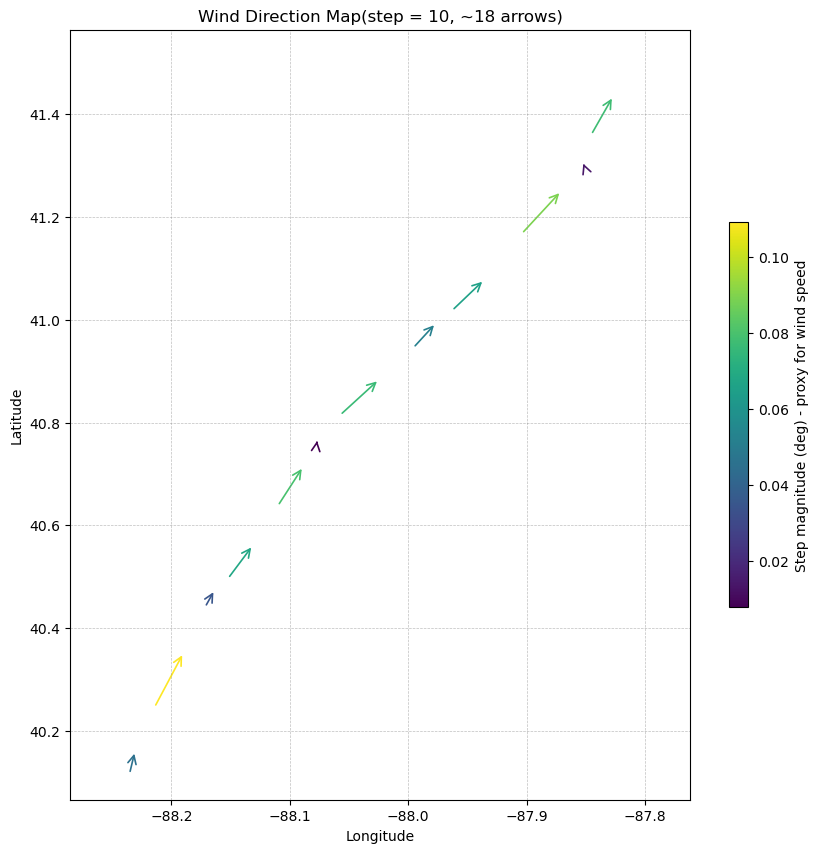

In [109]:
def plot_wind_map(lats, lons, step, title, out_path):
   """
   Plot a wind direction map showing the balloon's route with arrows.


   This function should:
   1. Create a matplotlib figure and axis.
   2. Loop through the GPS data with a stride of (2 * step) to create
      non-overlapping arrow segments. For each segment from index i to
      i + step, compute:
 - du = longitude difference (lons[i+step] - lons[i])
      - dv = latitude difference (lats[i+step] - lats[i])
      - speed = magnitude of (du, dv) using math.sqrt
   3. Normalize the speed values and use a colormap (e.g. "viridis")
      to assign a color to each arrow based on its speed.
   4. Draw each arrow using matplotlib.patches.FancyArrowPatch with
      the computed start point, end point, and color.
   5. Add a colorbar, axis labels, title, and grid.
   6. Save the figure to out_path.


   Args:
       lats (list):    List of latitude values from GPS data.
       lons (list):    List of longitude values from GPS data.
       step (int):     Number of rows between arrow start and end.
       title (str):    Title for the plot.
       out_path (str): File path to save the output figure.
   """
   # TODO: Create a figure and axis using plt.subplots()
   lats = np.array(lats)
   lons = np.array(lons)
   fig = plt.figure(figsize=(10, 10))
   ax = fig.add_subplot(1,1,1)


   # TODO: Loop through the data to build arrow segments
   #       Use range(0, len(lats) - step, 2 * step) so arrows
   #       don't share start/end points
   #       For each segment, compute du, dv, and speed
   speed_in = []
   for i in range(0, len(lats) - step, 2 * step):
      du = lons[i + step] - lons[i]
      dv = lats[i + step] - lats[i]
      speed = np.sqrt(du**2 + dv**2)
      speed_in.append(speed)

   # TODO: Normalize speeds using mcolors.Normalize and get a
   # colormap using cm.get_cmap("viridis")

   norm = mcolors.Normalize(vmin=min(speed_in), vmax=max(speed_in))
   # cmap = cm.get_cmap("viridis")
   cmap = matplotlib.colormaps["viridis"]
  

  

   # TODO: Draw each arrow using mpatches.FancyArrowPatch
   #       Set arrowstyle, linewidth, color from colormap
   for idx, i in enumerate(range(0, len(lats) - step, 2 * step)):
      du = lons[i + step] - lons[i]
      dv = lats[i + step] - lats[i]
      color = cmap(norm(speed_in[idx]))
      arrow = mpatches.FancyArrowPatch(
         (lons[i], lats[i]),
         (lons[i + step], lats[i + step]),
         arrowstyle='->',
         linewidth=1.2,
         color=color,
         mutation_scale=15,
         transform=ax.transData,
        )
      ax.add_patch(arrow)

   # TODO: Add a colorbar using cm.ScalarMappable
   sm = cm.ScalarMappable(cmap=cmap, norm=norm)
   sm.set_array([])
   fig.colorbar(sm, ax=ax, label="Step magnitude (deg) - proxy for wind speed", shrink = 0.5)

   # TODO: Set axis labels, title, aspect ratio, and grid
   ax.set_xlabel("Longitude")
   ax.set_ylabel("Latitude")
   ax.set_title(title)

   ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5, color='gray')
   ax.set_xlim(min(lons) - 0.05, max(lons) + 0.05)
   ax.set_ylim(min(lats) - 0.05, max(lats) + 0.05)


   # print(f"lats range: {min(lats)} to {max(lats)}")
   # print(f"lons range: {min(lons)} to {max(lons)}")
    
   # TODO: Save the figure using plt.savefig()

   #Criteria Step 1a in submission and grading) :Python used to create windmap(V), correct wind direction(?), colors to indicate wind speed(V), easy to digest wind map(V)
   plt.savefig(out_path)  
   plt.show()         
   pass

def main():
   """
   Main function that loads GPS data and generates the wind map.
   """
   # Load GPS data from the provided CSV file
   # df =  pd.read_csv('Data/gps_data.csv')
   times, lats, lons = load_gps("Data/gps_data.csv") #relative path from root (ran in Jupyter NB)

   # Generate wind direction map
   plot_wind_map(lats, lons,step=10,title="Wind Direction Map(step = 10, ~18 arrows)",out_path="wind_map.png",)


if __name__ == "__main__":
   main()
